# Trial 1 - Random Forest (Efficient vs Large vs Feature Selection)
**Goal:** Compare three Random Forest strategies to balance accuracy and model efficiency.

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

RANDOM_STATE = 42
TARGET = "Survived"
np.random.seed(RANDOM_STATE)

In [2]:
# Load data
df = pd.read_csv("titanic_augmented.csv")

# Quick sanity checks
print("Shape:", df.shape)
print(df[TARGET].value_counts(normalize=True))

Shape: (891, 26)
Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


## Quick EDA (Info, Describe, Missingness, Skewness)

In [3]:
# Preview data
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare  ... is_alone ticket_group_size  \
0      0         A/5 21171   7.2500  ...        0                 1   
1      0          PC 17599  71.2833  ...        0                 1   
2      0  STON/O2. 3101282   7.9250  ...        1                 1   
3      0            113803  53.1000 

In [4]:
# Data types and summary stats
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   PassengerId        891 non-null    int64  
 1   Survived           891 non-null    int64  
 2   Pclass             891 non-null    int64  
 3   Name               891 non-null    object 
 4   Sex                891 non-null    object 
 5   Age                714 non-null    float64
 6   SibSp              891 non-null    int64  
 7   Parch              891 non-null    int64  
 8   Ticket             891 non-null    object 
 9   Fare               891 non-null    float64
 10  Cabin              204 non-null    object 
 11  Embarked           889 non-null    object 
 12  name_length        891 non-null    int64  
 13  title              891 non-null    object 
 14  title_group        891 non-null    object 
 15  family_size        891 non-null    int64  
 16  is_alone           891 non

In [5]:
# Missingness
missing_pct = df.isna().mean().sort_values(ascending=False)
print(missing_pct.head(15))

cabin_room_number    0.775533
Cabin                0.771044
Age                  0.198653
Embarked             0.002245
Survived             0.000000
Sex                  0.000000
SibSp                0.000000
Pclass               0.000000
Name                 0.000000
PassengerId          0.000000
Fare                 0.000000
Ticket               0.000000
Parch                0.000000
name_length          0.000000
title_group          0.000000
dtype: float64


In [6]:
# Cardinality for categorical columns
cat_cols_eda = df.select_dtypes(exclude="number").columns
print(df[cat_cols_eda].nunique().sort_values(ascending=False))

Name           891
Ticket         681
Cabin          147
title           17
cabin_deck       9
title_group      5
Embarked         3
Sex              2
dtype: int64


In [7]:
# Skewness for numeric columns
num_cols_eda = df.select_dtypes(include="number").columns
print(df[num_cols_eda].skew().sort_values(ascending=False))

Fare                 4.787317
fare_per_person      4.380563
SibSp                3.695352
Parch                2.749117
family_size          2.727441
ticket_group_size    2.220638
name_word_count      1.895546
name_length          1.392643
age_fare_ratio       1.314309
cabin_room_number    0.607887
Survived             0.478523
Age                  0.389108
service_id           0.077624
cabin_score          0.032099
PassengerId          0.000000
booking_reference   -0.037773
is_alone            -0.420431
Pclass              -0.630548
dtype: float64


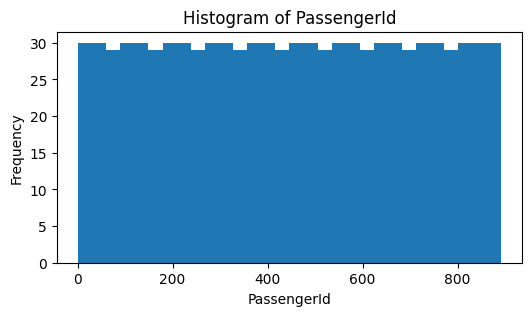

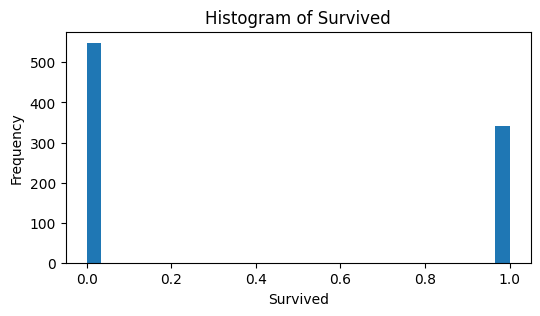

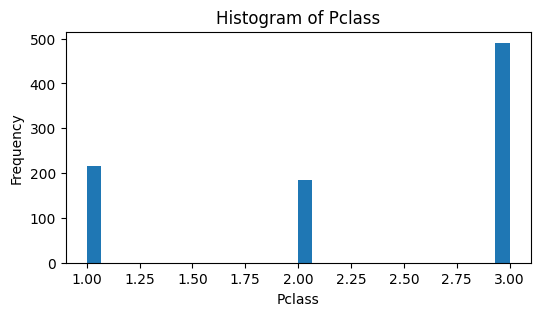

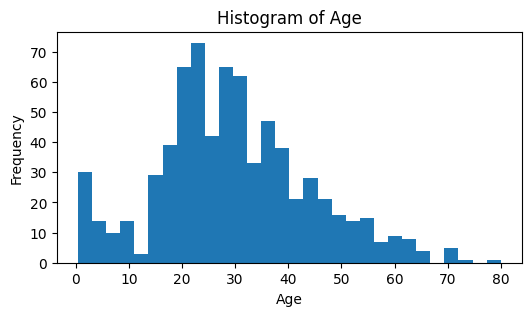

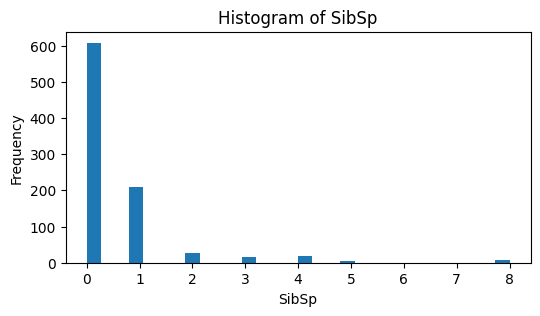

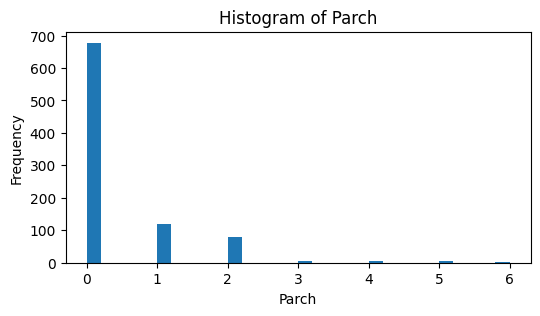

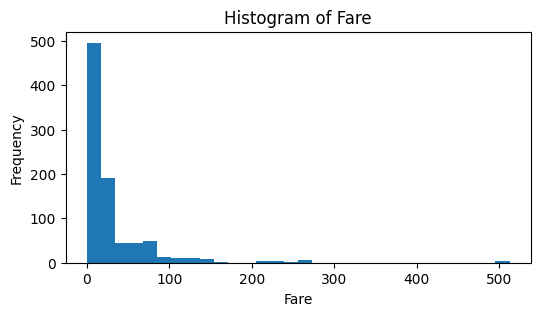

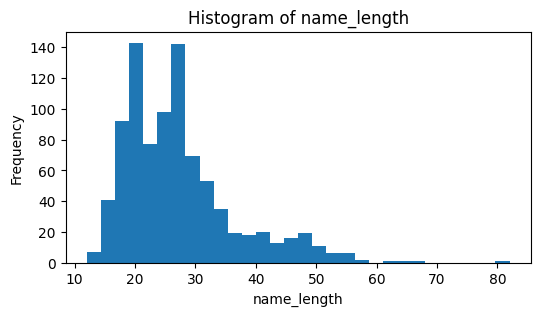

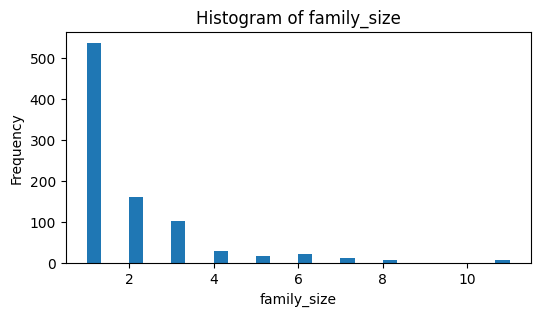

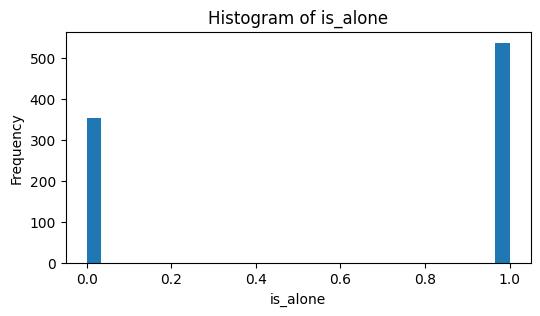

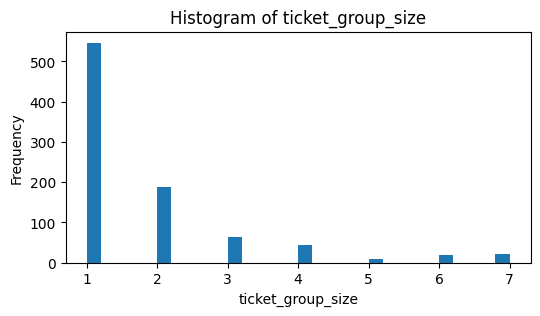

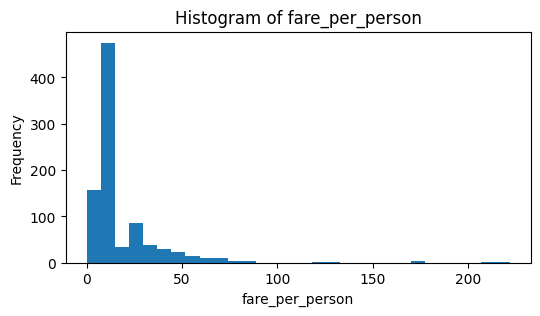

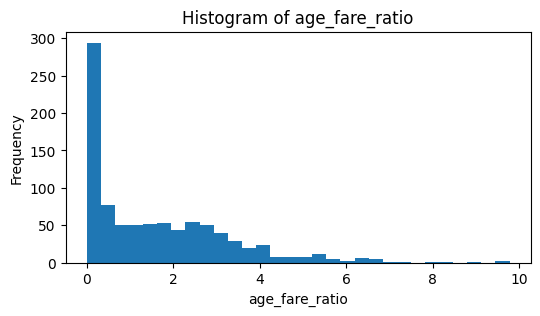

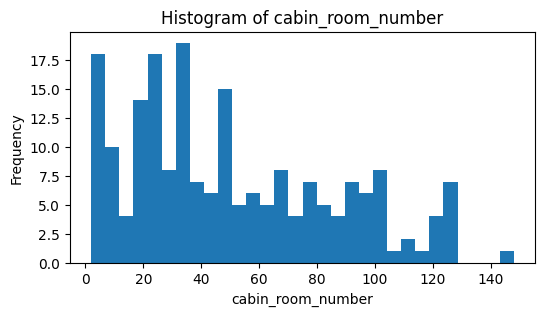

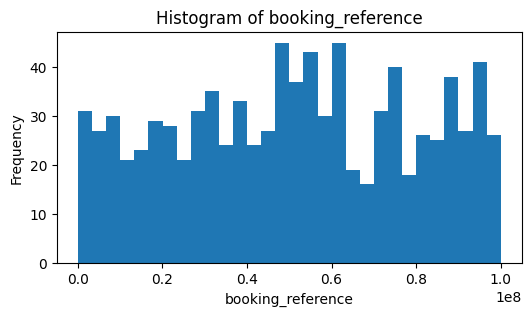

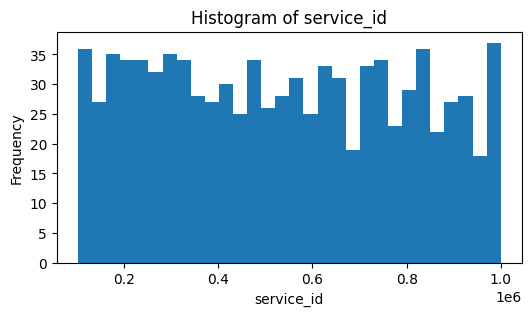

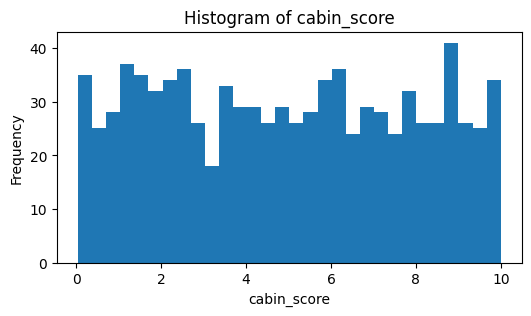

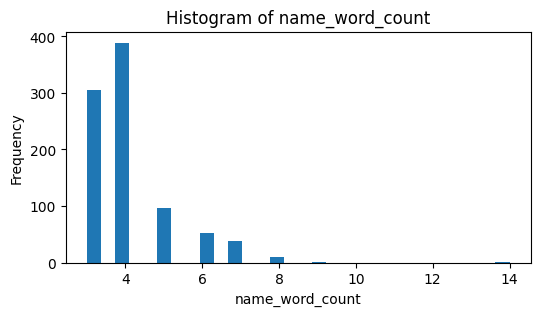

In [8]:
# Histograms for numeric columns (skewness visualization)
import matplotlib.pyplot as plt

for col in num_cols_eda:
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.hist(df[col].dropna(), bins=30)
    ax.set(title=f"Histogram of {col}", xlabel=col, ylabel="Frequency")
    plt.show()

## Purpose
We compare three models using the same train/test split and CV settings:
1) Feature engineering (efficient drop list + new features)
2) Large model (keep more columns)
3) Correlation + RF feature selection (remove weak features)

In [9]:
# Shared train/test split indices (fair comparison)
train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=df[TARGET]
)

## Model 1 - Feature Engineering (Updated)
Purpose: add structured features that capture titles, family structure, cabin info, age/fare bins, ticket groups, and key interactions.


In [10]:
# Feature engineering function
# (No leakage: uses only input features, no target)
def engineer_features(df_in):
    df_out = df_in.copy()

    # Title extraction from Name
    if "Name" in df_out.columns:
        title = df_out["Name"].str.extract(r",\s*([^\.]+)\.", expand=False)
        title = title.replace({"Mlle": "Miss", "Mme": "Mrs", "Ms": "Miss"})
        title = title.fillna("Unknown")
        common_titles = ["Mr", "Mrs", "Miss", "Master"]
        title = title.where(title.isin(common_titles), "Rare")
        df_out["Title"] = title

    # Family features
    if "SibSp" in df_out.columns and "Parch" in df_out.columns:
        df_out["FamilySize"] = df_out["SibSp"] + df_out["Parch"] + 1
        df_out["IsAlone"] = (df_out["FamilySize"] == 1).astype(int)
        df_out["FamilySizeGroup"] = pd.cut(
            df_out["FamilySize"],
            bins=[0, 1, 4, 11],
            labels=["Alone", "Small", "Large"]
        )

    # Cabin features
    if "Cabin" in df_out.columns:
        df_out["HasCabin"] = df_out["Cabin"].notna().astype(int)
        df_out["Deck"] = df_out["Cabin"].str[0].fillna("Unknown")

    # Age features
    if "Age" in df_out.columns:
        df_out["AgeMissing"] = df_out["Age"].isna().astype(int)
        df_out["AgeBin"] = pd.cut(
            df_out["Age"],
            bins=[0, 12, 18, 35, 60, 200],
            labels=["Child", "Teen", "Adult", "Middle", "Senior"]
        )

    # Fare features
    if "Fare" in df_out.columns:
        df_out["FareMissing"] = df_out["Fare"].isna().astype(int)
        if "FamilySize" in df_out.columns:
            df_out["FarePerPerson"] = df_out["Fare"] / df_out["FamilySize"]
        else:
            df_out["FarePerPerson"] = df_out["Fare"]
        df_out["FareBin"] = pd.cut(
            df_out["Fare"],
            bins=[0, 10, 20, 50, 100, 1000],
            labels=["Low", "Mid", "High", "VeryHigh", "Luxury"]
        )

    # Ticket features
    if "Ticket" in df_out.columns:
        ticket_counts = df_out["Ticket"].fillna("Unknown").value_counts()
        df_out["TicketGroupSize"] = df_out["Ticket"].fillna("Unknown").map(ticket_counts)

    # Interaction features
    if "Sex" in df_out.columns and "Pclass" in df_out.columns:
        df_out["Sex_Pclass"] = df_out["Sex"].astype(str) + "_" + df_out["Pclass"].astype(str)

    return df_out

In [11]:
# Efficient drop list
# (high-cardinality, mostly-missing, or ID-like)
drop_cols_eff = [
    "Name", "Ticket", "Cabin", "cabin_room_number",
    "PassengerId", "service_id", "booking_reference",
    "title"
]

# Build feature engineered dataset
_df_fe = engineer_features(df)

# Quick check engineered features
engineered_cols = [
    "Title", "FamilySize", "IsAlone", "FamilySizeGroup",
    "HasCabin", "Deck", "AgeMissing", "AgeBin",
    "FareMissing", "FarePerPerson", "FareBin",
    "TicketGroupSize", "Sex_Pclass"
]
engineered_cols = [c for c in engineered_cols if c in _df_fe.columns]
print(_df_fe[engineered_cols].head())
print(_df_fe[engineered_cols].isna().mean().sort_values(ascending=False))

X_eff = _df_fe.drop(columns=[TARGET] + [c for c in drop_cols_eff if c in _df_fe.columns])
y = _df_fe[TARGET]

X_train_eff = X_eff.loc[train_idx]
X_test_eff = X_eff.loc[test_idx]

y_train = y.loc[train_idx]
y_test = y.loc[test_idx]

num_cols_eff = X_train_eff.select_dtypes(include="number").columns.tolist()
cat_cols_eff = X_train_eff.select_dtypes(exclude="number").columns.tolist()

log_cols_eff = [c for c in [
    "Fare", "fare_per_person", "FarePerPerson",
    "ticket_group_size", "TicketGroupSize",
    "family_size", "FamilySize",
    "SibSp", "Parch"
] if c in num_cols_eff]
num_cols_eff_no_log = [c for c in num_cols_eff if c not in log_cols_eff]

print("Efficient numeric:", num_cols_eff)
print("Efficient categorical:", cat_cols_eff)
print("Efficient log cols:", log_cols_eff)

  Title  FamilySize  IsAlone FamilySizeGroup  HasCabin     Deck  AgeMissing  \
0    Mr           2        0           Small         0  Unknown           0   
1   Mrs           2        0           Small         1        C           0   
2  Miss           1        1           Alone         0  Unknown           0   
3   Mrs           2        0           Small         1        C           0   
4    Mr           1        1           Alone         0  Unknown           0   

   AgeBin  FareMissing  FarePerPerson   FareBin  TicketGroupSize Sex_Pclass  
0   Adult            0        3.62500       Low                1     male_3  
1  Middle            0       35.64165  VeryHigh                1   female_1  
2   Adult            0        7.92500       Low                1   female_3  
3   Adult            0       26.55000  VeryHigh                2   female_1  
4   Adult            0        8.05000       Low                1     male_3  
AgeBin             0.198653
FareBin            0.016835
I

In [12]:
# Preprocessing pipeline (efficient + FE)
log_pipeline_eff = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log_transform", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
])

num_pipeline_eff = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

# OneHotEncoder compatibility across sklearn versions
try:
    ohe_eff = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe_eff = OneHotEncoder(handle_unknown="ignore", sparse=False)

cat_pipeline_eff = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("onehot", ohe_eff),
])

preprocessor_eff = ColumnTransformer(
    transformers=[
        ("log_num", log_pipeline_eff, log_cols_eff),
        ("num", num_pipeline_eff, num_cols_eff_no_log),
        ("cat", cat_pipeline_eff, cat_cols_eff),
    ],
    remainder="drop"
)

In [13]:
# Efficient param grid (fast but effective)
param_grid_fast = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [None, 10],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt", "log2"],
    "model__class_weight": [None, "balanced"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [14]:
# Train + tune efficient model
rf_eff = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=1
)

eff_model = Pipeline([
    ("preprocess", preprocessor_eff),
    ("model", rf_eff)
])

grid_eff = GridSearchCV(
    eff_model,
    param_grid=param_grid_fast,
    cv=cv,
    scoring="accuracy",
    n_jobs=1,
    verbose=1
)

grid_eff.fit(X_train_eff, y_train)

print("Best params (Efficient):", grid_eff.best_params_)
print("Best CV accuracy (Efficient):", grid_eff.best_score_)

Fitting 5 folds for each of 64 candidates, totalling 320 fits
Best params (Efficient): {'model__class_weight': None, 'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 200}
Best CV accuracy (Efficient): 0.8338121422960386


In [15]:
# Evaluate efficient model
best_eff = grid_eff.best_estimator_
y_pred_eff = best_eff.predict(X_test_eff)

print("Efficient test accuracy:", accuracy_score(y_test, y_pred_eff))
print("\nEfficient confusion matrix:\n", confusion_matrix(y_test, y_pred_eff))
print("\nEfficient classification report:\n", classification_report(y_test, y_pred_eff))

feature_count_eff = best_eff.named_steps["preprocess"].transform(X_train_eff).shape[1]
print("Efficient feature count:", feature_count_eff)

Efficient test accuracy: 0.7802690582959642

Efficient confusion matrix:
 [[117  20]
 [ 29  57]]

Efficient classification report:
               precision    recall  f1-score   support

           0       0.80      0.85      0.83       137
           1       0.74      0.66      0.70        86

    accuracy                           0.78       223
   macro avg       0.77      0.76      0.76       223
weighted avg       0.78      0.78      0.78       223

Efficient feature count: 75


## Model 2 - Large Model (More Features)

In [16]:
# Large model keeps more columns (only drop ID-like)
drop_cols_large = [
    "PassengerId", "service_id", "booking_reference"
]

X_large = df.drop(columns=[TARGET] + [c for c in drop_cols_large if c in df.columns])

X_train_large = X_large.loc[train_idx]
X_test_large = X_large.loc[test_idx]

num_cols_large = X_train_large.select_dtypes(include="number").columns.tolist()
cat_cols_large = X_train_large.select_dtypes(exclude="number").columns.tolist()

log_cols_large = [c for c in ["Fare", "fare_per_person", "ticket_group_size", "family_size", "SibSp", "Parch"] if c in num_cols_large]
num_cols_large_no_log = [c for c in num_cols_large if c not in log_cols_large]

print("Large numeric:", num_cols_large)
print("Large categorical:", cat_cols_large)
print("Large log cols:", log_cols_large)

Large numeric: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'name_length', 'family_size', 'is_alone', 'ticket_group_size', 'fare_per_person', 'age_fare_ratio', 'cabin_room_number', 'cabin_score', 'name_word_count']
Large categorical: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked', 'title', 'title_group', 'cabin_deck']
Large log cols: ['Fare', 'fare_per_person', 'ticket_group_size', 'family_size', 'SibSp', 'Parch']


In [17]:
# Preprocessing pipeline (large)
log_pipeline_large = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log_transform", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
])

num_pipeline_large = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

try:
    ohe_large = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe_large = OneHotEncoder(handle_unknown="ignore", sparse=False)

cat_pipeline_large = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("onehot", ohe_large),
])

preprocessor_large = ColumnTransformer(
    transformers=[
        ("log_num", log_pipeline_large, log_cols_large),
        ("num", num_pipeline_large, num_cols_large_no_log),
        ("cat", cat_pipeline_large, cat_cols_large),
    ],
    remainder="drop"
)

In [18]:
# Train + tune large model
rf_large = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=1
)

large_model = Pipeline([
    ("preprocess", preprocessor_large),
    ("model", rf_large)
])

grid_large = GridSearchCV(
    large_model,
    param_grid=param_grid_fast,
    cv=cv,
    scoring="accuracy",
    n_jobs=1,
    verbose=1
)

grid_large.fit(X_train_large, y_train)

print("Best params (Large):", grid_large.best_params_)
print("Best CV accuracy (Large):", grid_large.best_score_)

Fitting 5 folds for each of 64 candidates, totalling 320 fits
Best params (Large): {'model__class_weight': None, 'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 400}
Best CV accuracy (Large): 0.8397710694647065


In [19]:
# Evaluate large model
best_large = grid_large.best_estimator_
y_pred_large = best_large.predict(X_test_large)

print("Large test accuracy:", accuracy_score(y_test, y_pred_large))
print("\nLarge confusion matrix:\n", confusion_matrix(y_test, y_pred_large))
print("\nLarge classification report:\n", classification_report(y_test, y_pred_large))

feature_count_large = best_large.named_steps["preprocess"].transform(X_train_large).shape[1]
print("Large feature count:", feature_count_large)

Large test accuracy: 0.8026905829596412

Large confusion matrix:
 [[118  19]
 [ 25  61]]

Large classification report:
               precision    recall  f1-score   support

           0       0.83      0.86      0.84       137
           1       0.76      0.71      0.73        86

    accuracy                           0.80       223
   macro avg       0.79      0.79      0.79       223
weighted avg       0.80      0.80      0.80       223

Large feature count: 1378


## Model 3 - Correlation + RF Feature Selection

In [20]:
# Start from efficient drop list (no feature engineering for selection)
X_corr_base = df.drop(columns=[TARGET] + [c for c in drop_cols_eff if c in df.columns])

X_train_corr = X_corr_base.loc[train_idx]
X_test_corr = X_corr_base.loc[test_idx]

# Correlation on numeric features (training only)
num_cols_corr = X_train_corr.select_dtypes(include="number").columns
corr = X_train_corr[num_cols_corr].corrwith(y_train).abs().sort_values(ascending=False)

print("Top numeric correlations with Survived:")
print(corr.head(15))

TOP_N_NUM = 8
selected_num = corr.head(TOP_N_NUM).index.tolist()

cat_cols_corr = X_train_corr.select_dtypes(exclude="number").columns.tolist()

selected_cols = selected_num + cat_cols_corr

X_train_corr = X_train_corr[selected_cols]
X_test_corr = X_test_corr[selected_cols]

print("Selected numeric:", selected_num)
print("Selected categorical:", cat_cols_corr)

Top numeric correlations with Survived:
Pclass               0.355948
name_length          0.315351
Fare                 0.295120
fare_per_person      0.284228
name_word_count      0.263275
age_fare_ratio       0.237682
is_alone             0.216091
Parch                0.106585
Age                  0.095724
ticket_group_size    0.056017
family_size          0.050713
cabin_score          0.025265
SibSp                0.011725
dtype: float64
Selected numeric: ['Pclass', 'name_length', 'Fare', 'fare_per_person', 'name_word_count', 'age_fare_ratio', 'is_alone', 'Parch']
Selected categorical: ['Sex', 'Embarked', 'title_group', 'cabin_deck']


In [21]:
# Preprocess for correlation-selected dataset
num_cols_corr = X_train_corr.select_dtypes(include="number").columns.tolist()
cat_cols_corr = X_train_corr.select_dtypes(exclude="number").columns.tolist()

log_cols_corr = [c for c in ["Fare", "fare_per_person", "ticket_group_size", "family_size", "SibSp", "Parch"] if c in num_cols_corr]
num_cols_corr_no_log = [c for c in num_cols_corr if c not in log_cols_corr]

log_pipeline_corr = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log_transform", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
])

num_pipeline_corr = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

try:
    ohe_corr = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe_corr = OneHotEncoder(handle_unknown="ignore", sparse=False)

cat_pipeline_corr = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("onehot", ohe_corr),
])

preprocessor_corr = ColumnTransformer(
    transformers=[
        ("log_num", log_pipeline_corr, log_cols_corr),
        ("num", num_pipeline_corr, num_cols_corr_no_log),
        ("cat", cat_pipeline_corr, cat_cols_corr),
    ],
    remainder="drop"
)

In [22]:
# Feature selection using RF importance on transformed features
selector = SelectFromModel(
    RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=1
    ),
    threshold="median"
)

rf_corr = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=1
)

corr_model = Pipeline([
    ("preprocess", preprocessor_corr),
    ("select", selector),
    ("model", rf_corr)
])

grid_corr = GridSearchCV(
    corr_model,
    param_grid=param_grid_fast,
    cv=cv,
    scoring="accuracy",
    n_jobs=1,
    verbose=1
)

grid_corr.fit(X_train_corr, y_train)

print("Best params (Corr+RF):", grid_corr.best_params_)
print("Best CV accuracy (Corr+RF):", grid_corr.best_score_)

Fitting 5 folds for each of 64 candidates, totalling 320 fits
Best params (Corr+RF): {'model__class_weight': 'balanced', 'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 200}
Best CV accuracy (Corr+RF): 0.8203568623050164


In [23]:
# Evaluate correlation + RF selection model
best_corr = grid_corr.best_estimator_
y_pred_corr = best_corr.predict(X_test_corr)

print("Corr+RF test accuracy:", accuracy_score(y_test, y_pred_corr))
print("\nCorr+RF confusion matrix:\n", confusion_matrix(y_test, y_pred_corr))
print("\nCorr+RF classification report:\n", classification_report(y_test, y_pred_corr))

# Feature count after selection
feature_count_corr = best_corr.named_steps["select"].get_support().sum()
print("Corr+RF feature count:", feature_count_corr)

Corr+RF test accuracy: 0.7982062780269058

Corr+RF confusion matrix:
 [[117  20]
 [ 25  61]]

Corr+RF classification report:
               precision    recall  f1-score   support

           0       0.82      0.85      0.84       137
           1       0.75      0.71      0.73        86

    accuracy                           0.80       223
   macro avg       0.79      0.78      0.78       223
weighted avg       0.80      0.80      0.80       223

Corr+RF feature count: 14


## Summary Table

In [24]:
summary = pd.DataFrame([
    {
        "model": "FeatureEngineering",
        "cv_accuracy": grid_eff.best_score_,
        "test_accuracy": accuracy_score(y_test, y_pred_eff),
        "feature_count": int(feature_count_eff)
    },
    {
        "model": "Large",
        "cv_accuracy": grid_large.best_score_,
        "test_accuracy": accuracy_score(y_test, y_pred_large),
        "feature_count": int(feature_count_large)
    },
    {
        "model": "CorrRFSelect",
        "cv_accuracy": grid_corr.best_score_,
        "test_accuracy": accuracy_score(y_test, y_pred_corr),
        "feature_count": int(feature_count_corr)
    }
])

summary

,model,cv_accuracy,test_accuracy,feature_count
0,FeatureEngineering,0.833812,0.780269,75
1,Large,0.839771,0.802691,1378
2,CorrRFSelect,0.820357,0.798206,14
